<a href="https://colab.research.google.com/github/jakster448/lis5693/blob/main/lab-7/Lab_Assignment_7_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
import pandas as pd
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
url = "https://raw.githubusercontent.com/jakster448/lis5693/refs/heads/main/lab-4/imdb_reviews.csv"
df = pd.read_csv(url)

df = df[['review', 'sentiment']]
df.columns = ['message', 'label']

def get_sentiment(text):
    # Ensure text is a string to avoid errors
    return TextBlob(str(text)).sentiment.polarity

df['sentiment_score'] = df['message'].apply(get_sentiment)

print("--- TASK 1: SENTIMENT POLARITY STATS ---")
print(df['sentiment_score'].describe())
print("\n--- FIRST 5 ROWS WITH SCORES ---")
print(df.head())

--- TASK 1: SENTIMENT POLARITY STATS ---
count    5000.000000
mean        0.102096
std         0.164139
min        -0.850000
25%         0.004941
50%         0.101762
75%         0.206214
max         1.000000
Name: sentiment_score, dtype: float64

--- FIRST 5 ROWS WITH SCORES ---
                                             message label  sentiment_score
0  Lars Von Triers Europa is an extremely good fi...   pos         0.267262
1  I did watch all of the film through to the dis...   neg        -0.234921
2  I knew about but had never seen Grey Gardens, ...   pos         0.146753
3  Deep Shock plays out like a TV movie: a whole ...   neg         0.002976
4  Horrible film. About an old crusty painter who...   neg        -0.181127


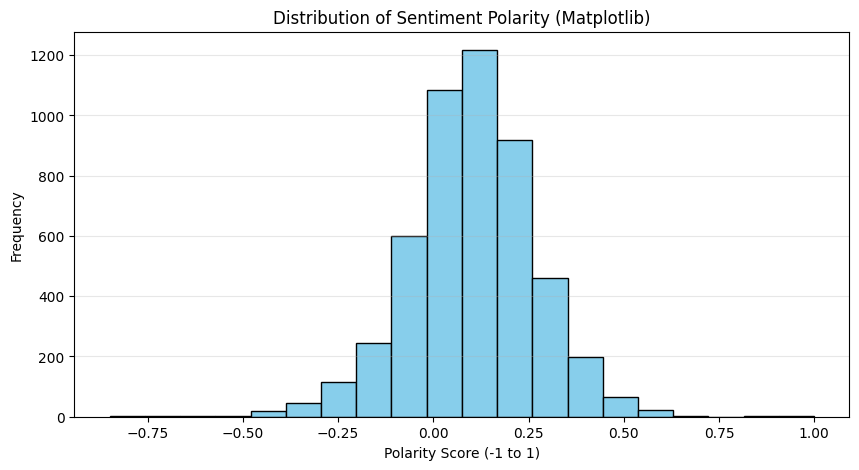

/tmp/ipykernel_2207/3745558120.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='sentiment_score', data=df, palette='Set2')


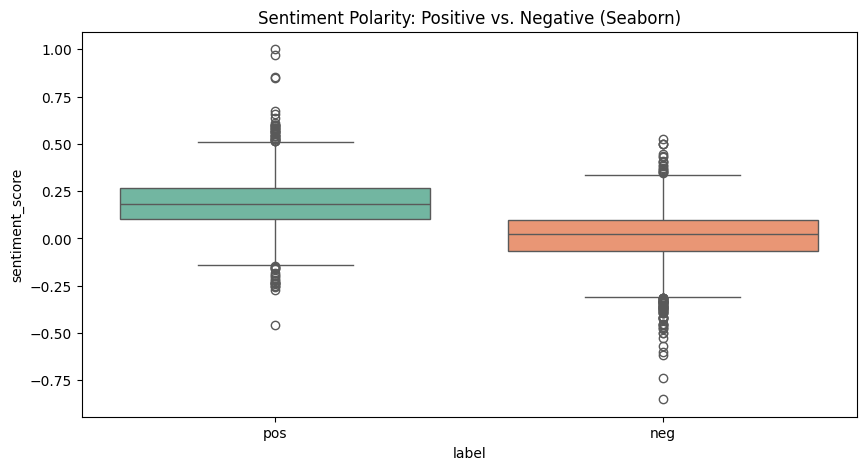

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(df['sentiment_score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Sentiment Polarity (Matplotlib)')
plt.xlabel('Polarity Score (-1 to 1)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='label', y='sentiment_score', data=df, palette='Set2')
plt.title('Sentiment Polarity: Positive vs. Negative (Seaborn)')
plt.show()


Task 1:

---


What is the 'text' field for your dataset?

*   The 'text' field for the IMDB dataset is the "review" column (which I renamed to message in my code), containing the full text of user movie reviews.


Which common column did you choose to merge your original dataset with the sentiment scores?
*   I didn't need to perform a traditional merge; instead, I appended the sentiment_score as a new column directly to the existing dataframe using the row index as the common identifier.

Briefly explain your sentiment polarity results using the `describe` method.
*   Looking at the Matplotlib histogram, most reviews fall between 0.0 and 0.25, indicating a slightly positive overall tone. The distribution is "bell-shaped" but centered slightly to the right of neutral (0.0).


Visualize and explain your sentiment results using two different visualization libraries.
*   The boxplot clearly shows that positive (pos) reviews have a higher median sentiment score (around 0.2) compared to negative (neg) reviews (around 0.05). However, there are many "outliers" (the dots) in the negative category where the text actually had a positive polarity score, likely due to sarcasm or reviewers using positive words to describe a bad movie.







Task 2:

---

What went well? What did not go well, or what challenges did you encounter?
*   The code successfully distinguished between positive and negative reviews. The visual gap between the two boxes in the Seaborn plot confirms that the sentiment tool is generally working as intended.
*   A major challenge is neutrality bias. Many negative reviews still have a polarity score above 0.0 because users might say "The acting was good, but the story was terrible." TextBlob sees "good" and "terrible" and averages them out to be neutral, missing the overall negative intent.




In what ways could sentiment analysis be integrated into your current or future professional or research work?
*  In the film industry, studios could use this to automatically scan thousands of social media posts on opening night to see if the "audience buzz" is trending positive or negative faster than waiting for official critics' reviews.


